Imports


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import joblib

Data Loading

In [10]:
import pandas as pd

print("Loading Data for KNN...")
df = pd.read_csv("UNSW_NB15_training-set.csv")   # ✅ file is in same folder
X = df.drop(columns=['id', 'label', 'attack_cat'], errors='ignore')
y = df['label']
print("Data loaded successfully. Shape:", df.shape)


Loading Data for KNN...
Data loaded successfully. Shape: (82332, 45)


Preprocessing & Loading Scaler

In [11]:
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

scaler = joblib.load('../models/scaler.pkl')
X_scaled = scaler.transform(X)

KNN Training & Serialization

In [12]:
print("Training KNN Model...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_scaled, y)
joblib.dump(knn, '../models/knn_model.pkl')
print("KNN Model saved successfully.")

Training KNN Model...
KNN Model saved successfully.


Predictions & Confusion Matrix Graph

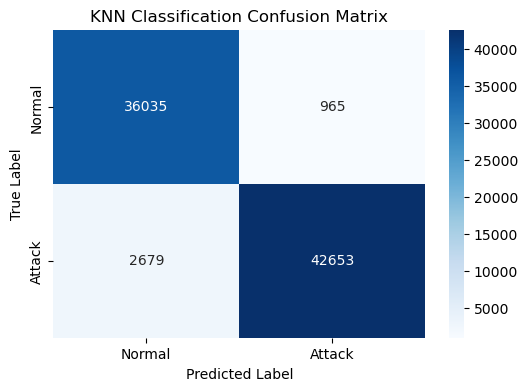

In [13]:

y_pred = knn.predict(X_scaled)
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title('KNN Classification Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()